In [1]:
__author__ = 'Sebastian F. Sanchez and LVM team'
__version__ = '20260416'
__datasets__ = ['SDSS-V LVM DAP (DRPVER=1.2.0, DAPVER = 1.2.0.251218, MJD=60191, EXPNUM=4297)']  
__keywords__ = ['M33','Mosaic','LVM','DR20','model spectra','tutorial']

# SDSS-V LVM DR20 Mosaic/Local Volume (M433) DAP tutorial 

**Purpose.** This notebook documents the process of generating the plots from several tiles analyzed  using the LVM DAP (https://github.com/sdss/lvmdap), doing Mosaics using the the DAP-files.

It teaches how to:
1. open and inspect several DR20 DAP products,
2. generate RGB maps and individual line maps,
4. explore the BPT diagrams based on the emission lines,
5. explore kinematics and radial structure,
6. inspect simple stellar-continuum products,

Although we focus here on the two pointings delivered for M33 included in the SDSS5 DR20, the workflow is broadly applicable to any Mosaic included in the DR20 LVM distribution. 

## Required Python dependencies

This notebook uses a small set of external Python packages in addition to the Python standard library. The main required dependencies are:

- **numpy**: numerical arrays and vectorized operations  
- **matplotlib**: plotting and figure generation  
- **astropy**: reading FITS files and handling tables  
- **sdss-access**: optional access to SDSS paths and remote files  
- **sdss-tree**: required by `sdss-access`  
- **gdown**: optional helper to download external template files from Google Drive

In practice:
- `math` and `pathlib` belong to the Python standard library and do **not** need installation.
- `mpl_toolkits.axes_grid1` is part of `matplotlib` and is installed automatically with it.
- If the template files are downloaded manually, `gdown` is **not required**.

### Recommended installation

Using `pip`:

```bash
pip install numpy matplotlib astropy sdss-access sdss-tree gdown

# Importing some routines that are needed for the plotting and analysis



In [2]:
import os

import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table,join
import matplotlib.colors as mpl_colors
from matplotlib import rcParams as rc
rc.update({'font.size': 19,\
           'font.weight': 900,\
           # 'text.usetex': True,\
           'path.simplify'           :   True,\
           'xtick.labelsize' : 19,\
           'ytick.labelsize' : 19,\
#           'xtick.major.size' : 3.5,\
#           'ytick.major.size' : 3.5,\
           'axes.linewidth'  : 2.0,\
               # Increase the tick-mark lengths (defaults are 4 and 2)
           'xtick.major.size'        :   6,\
           'ytick.major.size'        :   6,\
           'xtick.minor.size'        :   3,\
           'ytick.minor.size'        :   3,\
           'xtick.major.width'       :   1,\
           'ytick.major.width'       :   1,\
           'lines.markeredgewidth'   :   1,\
           'legend.numpoints'        :   1,\
           'xtick.minor.width'       :   1,\
           'ytick.minor.width'       :   1,\
           'legend.frameon'          :   False,\
           'legend.handletextpad'    :   0.3,\
           'font.family'    :   'serif',\
           'mathtext.fontset'        :   'stix',\
           'axes.facecolor' : "w",\
           
          })
import math
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.io import fits
from astropy.table import vstack as tab_vstack
# Import the sdss_access package to get the data


# Tools for downloading the RSP templates
import gdown 
from pathlib import Path

from sdss_access import Access
access = Access(release='dr20', verbose=True)

import warnings

warnings.simplefilter("ignore")

In [3]:
def read_DAP_file(dap_file,verbose=False):
    dap_hdu=fits.open(dap_file)
    tab_PT=Table(dap_hdu['PT'].data)
    tab_RSP=Table(dap_hdu['RSP'].data)
    tab_COEFFS=Table(dap_hdu['COEFFS'].data)
    tab_PE=Table(dap_hdu['PM_ELINES'].data)
    tab_NPE_B=Table(dap_hdu['NP_ELINES_B'].data)
    tab_NPE_R=Table(dap_hdu['NP_ELINES_R'].data)
    tab_NPE_I=Table(dap_hdu['NP_ELINES_I'].data)
    kel_ext = 0
    try:
        kel_ext = 1
        tab_KEL=Table(dap_hdu['PM_KEL'].data)
    except:
        kel_ext = 0
        print('No PM_KEL extension')

    sig_ext = 0
    try:
        sig_ext = 1
        tab_SIGMA = Table(dap_hdu['ELINES_SIGMA_CHI'].data)
    except:
        sig_ext = 0
        print('No SIGMA_CHI extension')

    #
    # Rename some entries!
    #
    tab_RSP.rename_column('Av','Av_st')
    tab_RSP.rename_column('e_Av','e_Av_st')
    tab_RSP.rename_column('z','z_st')
    tab_RSP.rename_column('e_z','e_z_st')
    tab_RSP.rename_column('disp','disp_st')
    tab_RSP.rename_column('e_disp','e_disp_st')
    tab_RSP.rename_column('flux','flux_st')
    tab_RSP.rename_column('redshift','redshift_st')
    tab_RSP.rename_column('med_flux','med_flux_st')
    tab_RSP.rename_column('e_med_flux','e_med_flux_st')
    tab_RSP.rename_column('sys_vel','vel_st')
    #
    # Parametric elines
    #
    tab_PE.rename_column('flux','flux_pe')
    tab_PE.rename_column('e_flux','e_flux_pe')
    tab_PE.rename_column('disp','disp_pe')
    tab_PE.rename_column('e_disp','e_disp_pe')
    tab_PE.rename_column('vel','vel_pe')
    tab_PE.rename_column('e_vel','e_vel_pe')

    if (kel_ext == 1):
        tab_KEL.rename_column('flux','flux_pek')
        tab_KEL.rename_column('e_flux','e_flux_pek')
        tab_KEL.rename_column('disp','disp_pek')
        tab_KEL.rename_column('e_disp','e_disp_pek')
        tab_KEL.rename_column('vel','vel_pek')
        tab_KEL.rename_column('e_vel','e_vel_pek')
    #
    # id	id_fib	rsp	TEFF	LOGG	META	ALPHAM	COEFF	Min.Coeff	log(M/L)	AV	N.Coeff	Err.Coeff
    #
    tab_COEFFS.rename_column('rsp','id_rsp')
    tab_COEFFS.rename_column('TEFF','Teff_rsp')
    tab_COEFFS.rename_column('LOGG','Log_g_rsp')
    tab_COEFFS.rename_column('META','Fe_rsp')
    tab_COEFFS.rename_column('ALPHAM','alpha_rsp')
    tab_COEFFS.rename_column('COEFF','W_rsp')
    tab_COEFFS.rename_column('Min.Coeff','min_W_rsp')
    tab_COEFFS.rename_column('log(M/L)','log_ML_rsp')
    tab_COEFFS.rename_column('AV','Av_rsp')
    tab_COEFFS.rename_column('N.Coeff','n_W_rsp')
    tab_COEFFS.rename_column('Err.Coeff','e_W_rsp')
    
    tab_DAP=Table(dap_hdu['PT'].data)
    tab_DAP=join(tab_DAP,tab_RSP,keys=['id'],join_type='left')
    tab_DAP=join(tab_DAP,tab_NPE_B,keys=['id'],join_type='left')
    tab_DAP=join(tab_DAP,tab_NPE_R,keys=['id'],join_type='left')
    tab_DAP=join(tab_DAP,tab_NPE_I,keys=['id'],join_type='left')

    #
    # order parametric emission line table
    #
    mask_elines = (tab_PE['model']=='eline')
    tab_PE = tab_PE[mask_elines]
    
    a_wl = np.unique(tab_PE['wl'])
    I=0
    for wl_now in a_wl:
        if (wl_now>0.0):
            tab_PE_now=tab_PE[tab_PE['wl']==wl_now]
            tab_PE_tmp=tab_PE_now['id','flux_pe','e_flux_pe','disp_pe','e_disp_pe','vel_pe','e_vel_pe']
            for cols in tab_PE_tmp.colnames:        
                if (cols != 'id'):
                    tab_PE_tmp.rename_column(cols,f'{cols}_{wl_now}')
            if (I==0):
                tab_PE_ord=tab_PE_tmp
            else:
                tab_PE_ord=join(tab_PE_ord,tab_PE_tmp,keys=['id'],join_type='left')
            I=I+1        
    tab_DAP=join(tab_DAP,tab_PE_ord,keys=['id'],join_type='left')


    #
    # order parametric emission line table with fixed kinematics
    #
    if (kel_ext == 1):
        mask_elines = (tab_KEL['model']=='eline')
        tab_KEL = tab_KEL[mask_elines]
    
        a_wl = np.unique(tab_KEL['wl'])
        I=0
        for wl_now in a_wl:
            if (wl_now>0.0):
                tab_KEL_now=tab_KEL[tab_KEL['wl']==wl_now]
                tab_KEL_tmp=tab_KEL_now['id','flux_pek','e_flux_pek','disp_pek','e_disp_pek','vel_pek','e_vel_pek']
                for cols in tab_KEL_tmp.colnames:        
                    if (cols != 'id'):
                        tab_KEL_tmp.rename_column(cols,f'{cols}_{wl_now}')
                if (I==0):
                    tab_KEL_ord=tab_KEL_tmp
                else:
                    tab_KEL_ord=join(tab_KEL_ord,tab_KEL_tmp,keys=['id'],join_type='left')
                I=I+1        
        tab_DAP=join(tab_DAP,tab_KEL_ord,keys=['id'],join_type='left')

    #
    # Order COEFFS table
    #
    a_rsp=np.unique(tab_COEFFS['id_rsp'])
    for I,rsp_now in enumerate(a_rsp):
        tab_C_now=tab_COEFFS[tab_COEFFS['id_rsp']==rsp_now]
        tab_C_tmp=tab_C_now['id','Teff_rsp', 'Log_g_rsp', 'Fe_rsp',\
                            'alpha_rsp', 'W_rsp', 'min_W_rsp',\
                            'log_ML_rsp', 'Av_rsp', 'n_W_rsp', 'e_W_rsp']
        for cols in tab_C_tmp.colnames:        
            if (cols != 'id'):
                tab_C_tmp.rename_column(cols,f'{cols}_{rsp_now}')
        if (I==0):
            tab_C_ord=tab_C_tmp
        else:
            tab_C_ord=join(tab_C_ord,tab_C_tmp,keys=['id'],join_type='left')
    tab_DAP=join(tab_DAP,tab_C_ord,keys=['id'],join_type='left')

    if (sig_ext == 1):
        tab_DAP=join(tab_DAP,tab_SIGMA,keys=['id'],join_type='left')
     
    if (verbose==True):
        print('---- ALL Table Columns -----')
        print('-------------------------------')
        print('|        PT                   |')
        print('-------------------------------')
        list_columns(tab_PT.colnames)
        print('----------------------------------')
        print('|        RSP                      |')
        print('----------------------------------')
        list_columns(tab_RSP.colnames)
        print('----------------------------------')
        print('|        PE_ord                   |')
        print('----------------------------------')
        list_columns(tab_PE_ord.colnames)
        if (kel_ext == 1):
            print('----------------------------------')
            print('|        PEK_ord                   |')
            print('----------------------------------')
            list_columns(tab_KEL_ord.colnames)
        print('----------------------------------')
        print('|        NPE_B                    |')
        print('----------------------------------')
        list_columns(tab_NPE_B.colnames,3)
        print('----------------------------------')
        print('|        NPE_R                    |')
        print('----------------------------------')
        list_columns(tab_NPE_R.colnames,3)
        print('----------------------------------')
        print('|        NPE_I                    |')
        print('----------------------------------')
        list_columns(tab_NPE_I.colnames,3)
        print('----------------------------------')
        print('|        C_ord                    |')
        print('----------------------------------')
        list_columns(tab_C_ord.colnames,4)
        if (sig_ext == 1):
            print('----------------------------------')
            print('|        SIGMA_CHI                   |')
            print('----------------------------------')
            list_columns(tab_SIGMA.colnames)
        
    return tab_DAP

def list_columns(obj, cols=4, columnwise=True, gap=2):
    """
    Print the given list in evenly-spaced columns.

    Parameters
    ----------
    obj : list
        The list to be printed.
    cols : int
        The number of columns in which the list should be printed.
    columnwise : bool, default=True
        If True, the items in the list will be printed column-wise.
        If False the items in the list will be printed row-wise.
    gap : int
        The number of spaces that should separate the longest column
        item/s from the next column. This is the effective spacing
        between columns based on the maximum len() of the list items.
    """

    sobj = [str(item) for item in obj]
    if cols > len(sobj): cols = len(sobj)
    max_len = max([len(item) for item in sobj])
    if columnwise: cols = int(math.ceil(float(len(sobj)) / float(cols)))
    plist = [sobj[i: i+cols] for i in range(0, len(sobj), cols)]
    if columnwise:
        if not len(plist[-1]) == cols:
            plist[-1].extend(['']*(len(sobj) - len(plist[-1])))
        plist = zip(*plist)
    printer = '\n'.join([
        ''.join([c.ljust(max_len + gap) for c in p])
        for p in plist])
    print(printer)


class scatter():
    def __init__(self,x,y,ax,size=1,**kwargs):
        self.n = len(x)
        self.ax = ax
        self.ax.figure.canvas.draw()
        self.size_data=size
        self.size = size
        self.sc = ax.scatter(x,y,s=self.size,**kwargs)
        self._resize()
        self.cid = ax.figure.canvas.mpl_connect('draw_event', self._resize)

    def _resize(self,event=None):
        ppd=72./self.ax.figure.dpi
        trans = self.ax.transData.transform
        s =  ((trans((1,self.size_data))-trans((0,0)))*ppd)[1]
        if s != self.size:
            self.sc.set_sizes(s**2*np.ones(self.n))
            self.size = s
            self._redraw_later()

    def _redraw_later(self):
        self.timer = self.ax.figure.canvas.new_timer(interval=10)
        self.timer.single_shot = True
        self.timer.add_callback(lambda : self.ax.figure.canvas.draw_idle())
        self.timer.start()
        


def gamma_scale(flux,gamma):
    return (flux/np.abs(flux))*(np.abs(flux))**gamma

def gamma_scale_abs(flux,gamma):
    return (np.abs(flux))**gamma





## 1. Load the DR20 DAP file

This cell defines the local directories, identifies the DR20 DAP product to use, and reads it into a single table.  
The chosen example are the two delivered DAP files on M33, expnums 5511 and 5512, using the experimental analysis
in which the contribution of the Milky Way has been removed (both ISM and stellar component), i.e, the files
labeled "LV_dap*".

From here on, `tab_DAP` is the main table used throughout the notebook, that in this case is constructed by stacking two individual DAP tables.


In here we have to options: (1.1) getting the data using the SDSS acccess procedure, or  (1.2) read it from a local directory. Select the option that is more suitable to you


In [ ]:
#####################################################
# (1.0) We define some basic working directories
#####################################################
drpver = "1.2.0"
dapver = '1.2.0.251218' 
DIR_CACHE = 'cache/'
DRVER = 'DR20'
DIR_DAP = 'dap_v1.2.0/'
DIR_FIG = 'figs/'
if not os.path.isdir(DIR_FIG):
    os.mkdir(DIR_FIG)
rsp = 'rsp108'
sn = 'sn20'
#
# You could define an array of expnums, tileids and mjds to define your ouwn Mosaic
#
a_expnum = np.array(['00005511','00005512'])
a_tileid = np.array(['11111','11111'])
#a_mjd = np.array([60191, 60191])
a_mjd = np.array([60212, 60212])
rsp = 'rsp108'
sn = 'sn20'
#i_expnum = int(expnum)

In [ ]:
kind = 'LV_dap'  
I=0
for expnum,tileid,mjd in zip(a_expnum, a_tileid, a_mjd):
    i_expnum = int(expnum)
    path_to_data_file = access.full('lvm_lv_dap',  drpver = drpver, dapver = dapver, tileid = tileid, mjd = mjd, expnum = i_expnum, rspid = rsp, snlevel = sn, daptype = 'dap')
    if not os.path.isfile(path_to_data_file):
        access.remote()
        access.add('lvm_lv_dap', drpver = drpver, dapver = dapver, tileid = tileid, mjd = mjd, expnum = i_expnum, rspid = rsp, snlevel = sn, daptype = 'dap')
        access.set_stream()
        access.commit()
    # # PATH to lvmDAP file
    # path_to_data_file = access.full('lvm_lv_dap',  drpver = drpver, dapver = dapver, tileid = tileid, mjd = mjd, expnum = i_expnum, rspid = rsp, snlevel = sn, daptype = 'dap')
    # print(path_to_data_file)
    tab_DAP_tmp=read_DAP_file(path_to_data_file,verbose=True)
    if (I==0):
        tab_DAP=tab_DAP_tmp
    else:
        tab_DAP=tab_vstack([tab_DAP,tab_DAP_tmp])
    I=I+1

authentication for netloc=data.sdss5.org set for username=sdss5
---- ALL Table Columns -----
-------------------------------
|        PT                   |
-------------------------------
id               dec              fiberid          star_id          
ra               mask             exposure         star_sep_arcsec  
----------------------------------
|        RSP                      |
----------------------------------
id             alpha          flux_st        Fe_MW          
MIN_CHISQ      e_alpha        redshift_st    e_Fe_MW        
Teff           Av_st          med_flux_st    alpha_MW       
e_Teff         e_Av_st        e_med_flux_st  e_alpha_MW     
Log_g          z_st           Teff_MW        vel_st         
e_Log_g        e_z_st         e_Teff_MW      log_ML         
Fe             disp_st        Log_g_MW       log_Mass       
e_Fe           e_disp_st      e_Log_g_MW                    
----------------------------------
|        PE_ord                   |
--------

# The 'Mosaic' table has two times the size of a single table

In [6]:
print(f'Length of the DAP table: {len(tab_DAP)}')

Length of the DAP table: 3508


## A. Quick-look spatial visualization with RGB maps

## 2. Define a helper to build RGB emission-line maps

This function converts three selected DAP columns into an RGB representation on the sky.  
It is especially useful for quick visual exploration because it combines three physically different tracers into a single image.

For nebular data, these composite maps are often the fastest way to identify ionization stratification:
- a high-ionization line can be mapped to one color,
- Hα or another recombination line to another,
- and a low-ionization line to a third one.

In the Helix paper, this kind of comparison is central to showing how the compact high-ionization core, the bright [O III] ring, and the low-ionization outer structures are spatially separated.

In [7]:
def map_plot_DAP_rgb(tab_DAP,\
                     rgb_key=('flux_pe_6583.45','flux_pe_6562.85','flux_pe_5006.84'), \
                     rgb_scale=(1.0,1.0,1.0),\
                 vmin=0, vmax=0, titles=('r','g','b'), filename='junk',\
                fsize=5, figs_dir='.',fig_type='png',\
                 gamma=1.0, sf=1.0, tab_pt=None,fs=18):

    rc.update({'font.size': fs*fsize/5,\
               'font.weight': 900,\
               # 'text.usetex': True,\
               'path.simplify'           :   True,\
               'xtick.labelsize' : fs*fsize/5,\
               'ytick.labelsize' : fs*fsize/5,\
               'axes.linewidth'  : 2.0,\
               'xtick.major.size'        :   6,\
               'ytick.major.size'        :   6,\
               'xtick.minor.size'        :   3,\
               'ytick.minor.size'        :   3,\
               'xtick.major.width'       :   1,\
               'ytick.major.width'       :   1,\
               'lines.markeredgewidth'   :   1,\
               'legend.numpoints'        :   1,\
               'xtick.minor.width'       :   1,\
               'ytick.minor.width'       :   1,\
               'legend.frameon'          :   False,\
               'legend.handletextpad'    :   0.3,\
               'font.family'    :   'serif',\
               'mathtext.fontset'        :   'stix',\
               'axes.facecolor' : "w",\
               })
    
    X= tab_DAP['ra'].value
    Y= tab_DAP['dec'].value
    R=tab_DAP[rgb_key[2]].value  
    G=tab_DAP[rgb_key[1]].value    
    B=tab_DAP[rgb_key[0]].value 
    R = R * rgb_scale[0]
    G = G * rgb_scale[1]
    B = B * rgb_scale[2]
    RGB = np.stack((R, G, B), axis=1)
    if (vmin==vmax):
        vmin=np.nanmin(RGB)
        vmax=np.nanmax(RGB)
    print(f'min/max:{vmin}/{vmax}')
    r = (R-vmin)/(vmax-vmin)
    g = (G-vmin)/(vmax-vmin)
    b = (B-vmin)/(vmax-vmin)

    r[r>1]=1
    r[r<0]=0
    b[b>1]=1
    b[b<0]=0
    r[r>1]=1
    r[r<0]=0    
    
    r = np.ma.filled(r, fill_value=0.0)
    g = np.ma.filled(g, fill_value=0.0)
    b = np.ma.filled(b, fill_value=0.0)

    r=r**gamma
    g=g**gamma
    b=b**gamma
    
#    print (r)
    r = np.ma.compressed(r)
    g = np.ma.compressed(g)
    b = np.ma.compressed(b)   


    #print(r,g,b)
    colors = np.stack((r, g, b), axis=1)
    colors[colors>1]=1
    colors[colors<0]=0
#    print(colors)
    fig,ax = plt.subplots(1,1,figsize=(fsize,fsize*0.95))
#    norm=mpl_colors.PowerNorm(vmin=0,vmax=1,gamma=gamma)
    scatter(X, Y, ax, color=colors, size=sf*35.6/3600)#, color=colors)
    ax.set_xlabel('Ra [deg]')#,fontsize=21)
    ax.set_ylabel('Dec [deg]')#,fontsize=21)
    xx = ax.get_xlim()
    yy = ax.get_ylim()
    ax.set_xlim(xx[1],xx[0])
    ax.text(xx[1]-0.03*(xx[1]-xx[0]),yy[1]-0.06*(yy[1]-yy[0]),titles[0],fontsize=fs*(fsize/5),color='tomato')
    ax.text(xx[1]-0.03*(xx[1]-xx[0]),yy[1]-0.12*(yy[1]-yy[0]),titles[1],fontsize=fs*(fsize/5),color='forestgreen')
    ax.text(xx[1]-0.03*(xx[1]-xx[0]),yy[1]-0.18*(yy[1]-yy[0]),titles[2],fontsize=fs*(fsize/5),color='steelblue')

    if (tab_pt != None):
        for tap_pt_now in tab_pt:
            ax.text(tab_pt['ra'],tab_pt['dec'],tab_pt['id'])
#    ax.set_aspect('equal', adjustable='box')
    try:
        plt.show()
    except:
        plt_show=False
    fig.tight_layout()
    fig.savefig(f'{figs_dir}/{filename}.{fig_type}', facecolor='white')
    plt.close()
    return colors

def search_col(tab,key):
    a_keys=[]
    for keys in tab.columns:
        if (keys.find(key)>-1):
            print(keys)
            a_keys.append(keys)
    return a_keys

This is a quick check of the available columns matching `[OII]`.  
It is useful before selecting line names for the maps, because DAP products often contain several measurements of the same transition, depending on whether the analysis is parametric, non-parametric, or from different iterations.

In [8]:
# We can search for the columns in the DAP table using the search_col function
# In this particular case we search for the [OII] emission line, which is a doublet at 3727.09 and 3729.88 Angstroms
oii_cols = search_col(tab_DAP,'[OII]')
# You could experiment with other entries in the DAP table.
# Columns involving Halpha
Ha_cols = search_col(tab_DAP,'_6562')
# Columns involving stellar analysis
st_cols = search_col(tab_DAP,'_st')


flux_[OII]_3726.03
flux_[OII]_3728.82
vel_[OII]_3726.03
vel_[OII]_3728.82
disp_[OII]_3726.03
disp_[OII]_3728.82
EW_[OII]_3726.03
EW_[OII]_3728.82
e_flux_[OII]_3726.03
e_flux_[OII]_3728.82
e_vel_[OII]_3726.03
e_vel_[OII]_3728.82
e_disp_[OII]_3726.03
e_disp_[OII]_3728.82
e_EW_[OII]_3726.03
e_EW_[OII]_3728.82
flux_[OII]_7318.92
flux_[OII]_7329.66
vel_[OII]_7318.92
vel_[OII]_7329.66
disp_[OII]_7318.92
disp_[OII]_7329.66
EW_[OII]_7318.92
EW_[OII]_7329.66
e_flux_[OII]_7318.92
e_flux_[OII]_7329.66
e_vel_[OII]_7318.92
e_vel_[OII]_7329.66
e_disp_[OII]_7318.92
e_disp_[OII]_7329.66
e_EW_[OII]_7318.92
e_EW_[OII]_7329.66
sigma_kms_[OII]_3726.03
sigma_kms_[OII]_3728.82
sigma_kms_[OII]_7318.92
sigma_kms_[OII]_7329.66
X_sq_[OII]_3726.03
fr_[OII]_3726.03
X_sq_[OII]_3728.82
fr_[OII]_3728.82
X_sq_[OII]_7318.92
fr_[OII]_7318.92
X_sq_[OII]_7329.66
fr_[OII]_7329.66
flux_Halpha_6562.85
vel_Halpha_6562.85
disp_Halpha_6562.85
EW_Halpha_6562.85
e_flux_Halpha_6562.85
e_vel_Halpha_6562.85
e_disp_Halpha_6562.85
e_

## 3. RGB map using the first parametric analysis (`pe`)

This RGB composite uses:
- red: [N II] 6583
- green: Hα
- blue: [O III] 5007

Because these columns come from the first parametric analysis, this view is useful mostly for comparison with later products.  
Physically, this combination is a classic way to visualize ionization structure:
- [O III] emphasizes the inner high-excitation gas,
- Hα traces the overall ionized nebula,
- [N II] highlights the lower-ionization outer layers and dense structures near the ionization front.

min/max:-100/5000.0


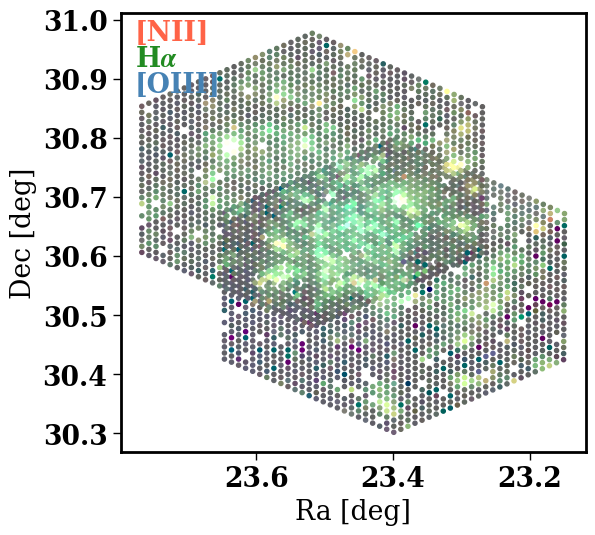

In [9]:
# 637.416/110230.7468
colors=map_plot_DAP_rgb(tab_DAP, \
                 rgb_key=('flux_pe_6583.45','flux_pe_6562.85','flux_pe_5006.84'), \
                 rgb_scale = (1,1,1), \
                 vmin=-100, vmax=5000.0,\
                 titles=('[NII]',r'H$\alpha$','[OIII]'), filename='Helix',\
                 fsize=6, figs_dir='figs',gamma=0.25,fig_type='png',fs=16, sf=0.95)

## 4. RGB map of faint diagnostic lines

This composite highlights much fainter transitions:
- [N II] 5755
- Hε
- [O III] 4363

These are astrophysically important because auroral and high-order Balmer lines are among the key diagnostics of electron temperature and line-measurement sensitivity.  
In the Helix paper, the ability to map lines like [O III] 4363 and [N II] 5755 over a large area is one of the strongest demonstrations of the depth and uniformity of the LVM+DAP analysis.

min/max:-50/450.0


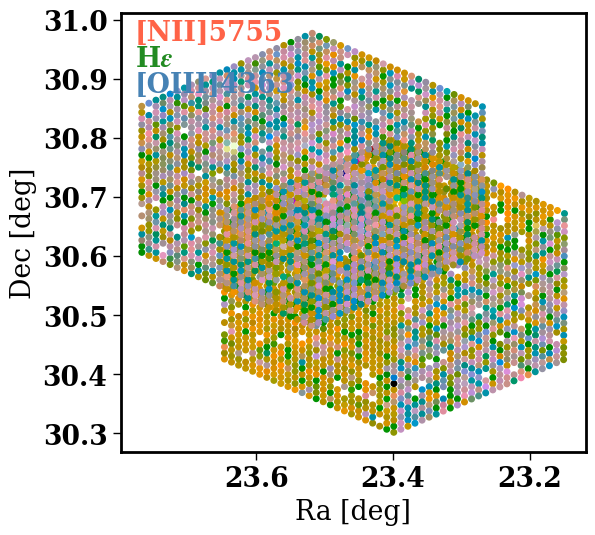

In [10]:
# 637.416/110230.7468
colors_w=map_plot_DAP_rgb(tab_DAP, \
                 rgb_key=('flux_[NII]_5754.59','flux_Hepsilon_3970.07','flux_[OIII]_4363.21'), \
                 rgb_scale = (1,0.1,1), \
                 vmin=-50, vmax=450.0,\
                 titles=('[NII]5755',r'H$\epsilon$','[OIII]4363'), filename='Helix_PN_faint',\
                 fsize=6, figs_dir='figs',gamma=0.25,fig_type='png',fs=16, sf=0.95)

This RGB map replaces the red channel with [S III] 9531, a high-ionization tracer in the near-infrared arm.  
Together with Hα and [O III], it helps compare how different ionization zones are sampled across the full LVM wavelength range.

It is also a useful reminder that the DAP products combine measurements from the blue, red, and infrared arms into a unified per-fiber analysis.

min/max:-10/2000.0


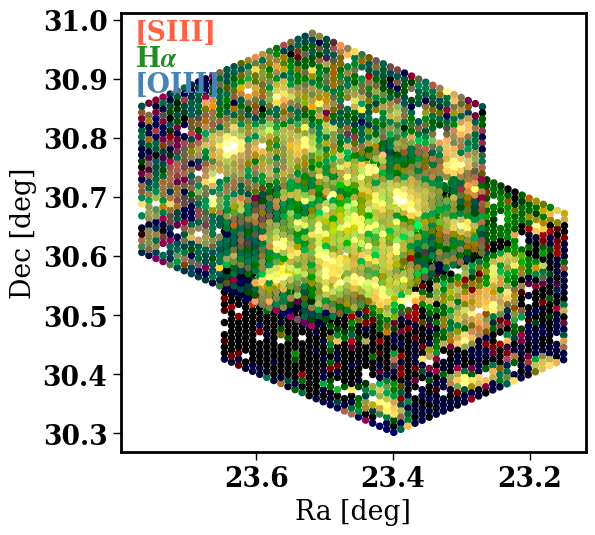

In [11]:
colors_t=map_plot_DAP_rgb(tab_DAP, \
                 rgb_key=('flux_[SIII]_9531.1','flux_Halpha_6562.85','flux_[OIII]_5006.84'), \
                 rgb_scale = (3,0.5,0.15), \
                 vmin=-10, vmax=2000.0,\
                 titles=('[SIII]',r'H$\alpha$','[OIII]'), filename='Helix_SIII',\
                 fsize=6, figs_dir='figs',gamma=0.25,fig_type='png',fs=16, sf=1.05)

## 5. BPT diagnostic diagrams and ionization structure

This cell shows three classical **BPT diagnostic diagrams**, comparing:
- log([O III] λ5007 / Hβ) vs log([N II] λ6583 / Hα)  
- log([O III] λ5007 / Hβ) vs log([S II] 6717,31 / Hα)  
- log([O III] λ5007 / Hβ) vs log([O II] 3727 / Hβ)  

These diagrams use ratios of strong emission lines to probe the **physical conditions and ionization mechanisms** of the gas. In particular:
- **[O III]/Hβ** traces the hardness of the ionizing radiation field and the ionization parameter,  
- **[N II]/Hα, [S II]/Hα, [O II]/Hβ** are sensitive to metallicity, density, and the structure of partially ionized zones. :contentReference[oaicite:0]{index=0}  

In galaxy studies, these diagrams are commonly used to distinguish between ionization sources (e.g., star formation vs AGN), since harder radiation fields enhance forbidden lines relative to recombination lines. :contentReference[oaicite:1]{index=1}  

In this notebook, each point corresponds to an individual **fiber**, and the color coding follows the RGB composite shown previously:
- **blue → [O III] (high-ionization gas)**  
- **green → Hα (overall ionized gas distribution)**  
- **red → [N II] (low-ionization gas / ionization front regions)**  

This color mapping helps connect the position of each point in the diagram with its spatial location in the nebula.


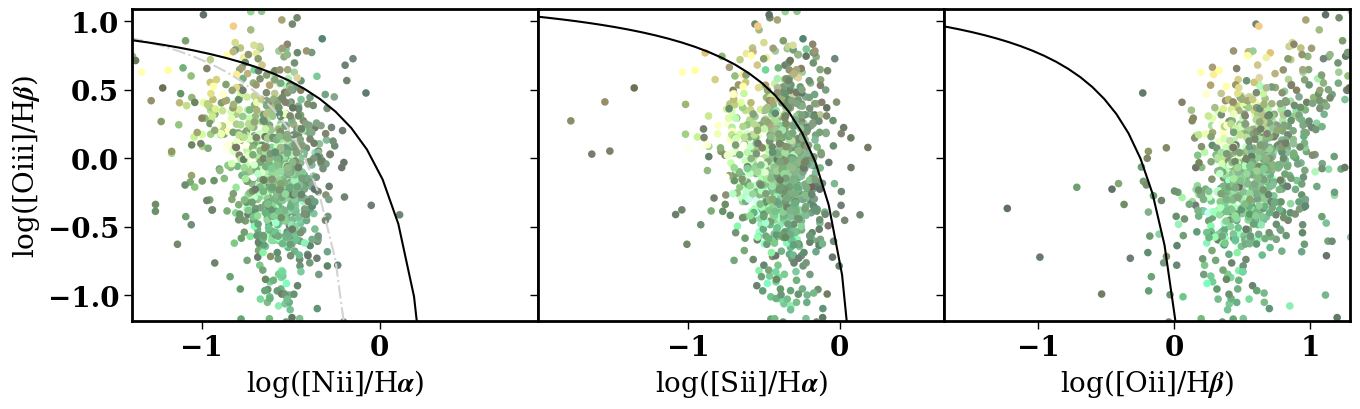

In [12]:
rc.update({'font.size': 20,\
           'font.weight': 900,\
           # 'text.usetex': True,\
           'path.simplify'           :   True,\
           'xtick.labelsize' : 20,\
           'ytick.labelsize' : 20,\
#           'xtick.major.size' : 3.5,\
#           'ytick.major.size' : 3.5,\
           'axes.linewidth'  : 2.0,\
               # Increase the tick-mark lengths (defaults are 4 and 2)
           'xtick.major.size'        :   6,\
           'ytick.major.size'        :   6,\
           'xtick.minor.size'        :   3,\
           'ytick.minor.size'        :   3,\
           'xtick.major.width'       :   1,\
           'ytick.major.width'       :   1,\
           'lines.markeredgewidth'   :   1,\
           'legend.numpoints'        :   1,\
           'xtick.minor.width'       :   1,\
           'ytick.minor.width'       :   1,\
           'legend.frameon'          :   False,\
           'legend.handletextpad'    :   0.3,\
           'font.family'    :   'serif',\
           'mathtext.fontset'        :   'stix',\
           'axes.facecolor' : "w",\
           
          })


mask_Ha = (tab_DAP['flux_Halpha_6562.85']>10) & (tab_DAP['flux_Halpha_6562.85']>2*tab_DAP['e_flux_Halpha_6562.85'])



Ha=tab_DAP['flux_Halpha_6562.85']
Hb=tab_DAP['flux_Hbeta_4861.36']
OIII=tab_DAP['flux_[OIII]_5006.84']
NII=tab_DAP['flux_[NII]_6583.45']
SII=tab_DAP['flux_[SII]_6716.44']+tab_DAP['flux_[SII]_6730.82']
OI=tab_DAP['flux_[OI]_6300.3']
OII=tab_DAP['flux_[OII]_3726.03']+tab_DAP['flux_[OII]_3728.82']
#tab_DAP['flux_pe_3726.03']+tab_DAP['flux_pe_3728.82']

map_dist=np.arange(len(Ha))

eHa=tab_DAP['e_flux_Halpha_6562.85']
eHb=tab_DAP['e_flux_Hbeta_4861.36']
eOIII=tab_DAP['e_flux_[OIII]_5006.84']
eNII=tab_DAP['e_flux_[NII]_6583.45']
eSII=np.sqrt(tab_DAP['e_flux_[SII]_6716.44']**2+tab_DAP['e_flux_[SII]_6730.82']**2)
eOI=tab_DAP['flux_[OI]_6300.3']
eOII=np.sqrt(tab_DAP['e_flux_[OII]_3726.03']**2+tab_DAP['e_flux_[OII]_3728.82']**2)
#tab_DAP['e_flux_pe_3726.03']+tab_DAP['e_flux_pe_3728.82']

#tab_DAP['e_flux_pe_9531.1']

O3=np.log10(OIII)-np.log10(Hb)
N2=np.log10(NII)-np.log10(Ha)
S2=np.log10(SII/Ha)
O1=np.log10(OI/Ha)
O2=np.log10(OII)-np.log10(Hb)
lEW_Ha = np.log10(np.abs(tab_DAP['EW_Halpha_6562.85']))
e_lEW_Ha = 0.4*np.abs(tab_DAP['e_EW_Halpha_6562.85']/tab_DAP['EW_Halpha_6562.85'])
nx = 2.5 #np.max(tab_DAP[mask_Ha]['R_Re'])
#
#
#
fig, axes = plt.subplots(1,3,figsize=(14,4.5), sharey=True, squeeze=False)
x_min1=-1.39
x_max1=0.89
y_min1=-1.29
y_max1=0.99

x=np.linspace(5*x_min1,2*x_max1,100)
cut_y=-0.7+0.2-3.67*x
cut_y2=-1.7+0.5-3.67*x
cut_y3=0.61/(x-0.05)+1.3
cut_y4=0.61/(x-0.47)+1.19
cut_y_SII=0.61/(x-0.3)+1.3;
cut_y_SII=0.61/(x-0.3)+1.3;
cut_y_SII_AGNs=1.89*(x)+0.76;
cut_y_OII=0.73/((x-0.3))+1.33;#+1.10;
cut_y_OII_AGNs=1.18*(x)+0.36;
cut_y_OIII_AGNs=1.14*(x)+0.36;
cm = plt.cm.get_cmap('viridis')
cax1=axes[0,0].scatter(N2[mask_Ha],O3[mask_Ha],color=colors[mask_Ha],edgecolor='None',s=30)
#                       c=map_dist[mask_Ha], marker='o', s=30, alpha=0.35, cmap=cm, vmin=0, vmax=nx)
cax2=axes[0,1].scatter(S2[mask_Ha],O3[mask_Ha],color=colors[mask_Ha],edgecolor='None',s=30)
cax3=axes[0,2].scatter(O2[mask_Ha],O3[mask_Ha],color=colors[mask_Ha],edgecolor='None',s=30)

#axes[0,0].scatter(N2,O3,alpha=0.75, marker='*', s=100,c='green')
#axes[0,1].scatter(S2,O3,alpha=0.75, marker='*', s=100,c='green')
#axes[0,2].scatter(O1,O3,alpha=0.75, marker='*', s=100,c='green')

axes[0,0].plot(x[x<0],cut_y3[x<0],'-.',color='lightgrey')
axes[0,0].plot(x[x<0.5],cut_y4[x<0.5],'-',color='black')
axes[0,1].plot(x[x<0.2],cut_y_SII[x<0.2],'-',color='black')
axes[0,2].plot(x[x<0.3],cut_y_OII[x<0.3],'-',color='black')


#plt.rcParams.update({'font.size': 16})
axes[0,0].set_ylabel(r'log([Oiii]/H$\beta$)')
axes[0,0].set_xlabel(r'log([Nii]/H$\alpha$)')
axes[0,1].set_xlabel(r'log([Sii]/H$\alpha$)')
axes[0,2].set_xlabel(r'log([Oii]/H$\beta$)')
axes[0,0].set_xlim(x_min1,x_max1)
axes[0,1].set_xlim(x_min1-0.6,x_max1-0.2)
axes[0,2].set_xlim(x_min1-0.3,x_max1+0.4)
axes[0,0].set_ylim(y_min1+0.1,y_max1+0.1)





plt.tight_layout()
plt.subplots_adjust(wspace=0)

fig.savefig(f'figs/BPT_ORION.png', facecolor='white')
plt.show()

#cax1=axes[0,2].scatter(N2[mask_Ha],O3[mask_Ha],c=log_EW_Ha[mask_Ha], marker='o', s=30, alpha=0.35, cmap=cm, vmin=-3, vmax=2.5)
#axes[0,2].plot(x[x<0],cut_y3[x<0],'r-.')
#axes[0,2].plot(x,cut_y4,'b-')
#cb1=add_colorbar(cax1)
#cb1.set_label(r'$log|EW(H\alpha)|$')

## Classical BPT diagrams, now including the [O I]-based diagnostic

This cell shows three classical emission-line diagnostic diagrams, using the same color coding adopted in the previous RGB maps:
- **blue**: [O III] λ5007  
- **green**: Hα  
- **red**: [N II] λ6583  

The panels correspond to:
- log([O III] λ5007 / Hβ) vs log([N II] λ6583 / Hα),
- log([O III] λ5007 / Hβ) vs log([S II] λλ6717,6731 / Hα),
- log([O III] λ5007 / Hβ) vs log([O I] λ6300 / Hα).

These are the classical **BPT / Veilleux-Osterbrock** diagnostics, widely used to compare different ionization regimes through strong optical line ratios. In galaxy studies, they are often used to separate gas ionized by young stars, AGN radiation, or shocks, with the standard demarcation curves shown here as reference. 

In this notebook, however, each point corresponds to an individual **fiber** in a **resolved nebula**, not to an integrated galaxy or a single globally ionized structure. Therefore, the location of the points in these diagrams should **not** be interpreted in the same straightforward classification sense used for galaxies. Instead, the distribution reflects **local variations** in excitation, ionization parameter, density, temperature, and the presence of partially ionized zones across the nebula. Spatially resolved line-ratio diagrams are useful because they connect the morphology seen in the RGB maps with the physical conditions of the gas. 

For the Helix Nebula, this means that fibers associated with the inner high-excitation regions tend to occupy different parts of the diagrams than fibers located in the outer low-ionization ring, where [N II], [S II], and [O I] become enhanced. This behavior is consistent with the ionization stratification discussed in the Helix analysis. 

The third panel uses **[O I] λ6300**, which is particularly interesting because it traces partially ionized gas and transition regions, but it must be interpreted with extra caution: in the Helix DAP analysis this line was identified as one of the transitions that can be significantly affected by imperfect night-sky subtraction, and an a posteriori background correction was applied to it. Therefore, structure seen in the [O I]-based diagram may partly reflect real nebular conditions and partly residual sky contamination if the correction is not properly taken into account. :contentReference[oaicite:3]{index=3}

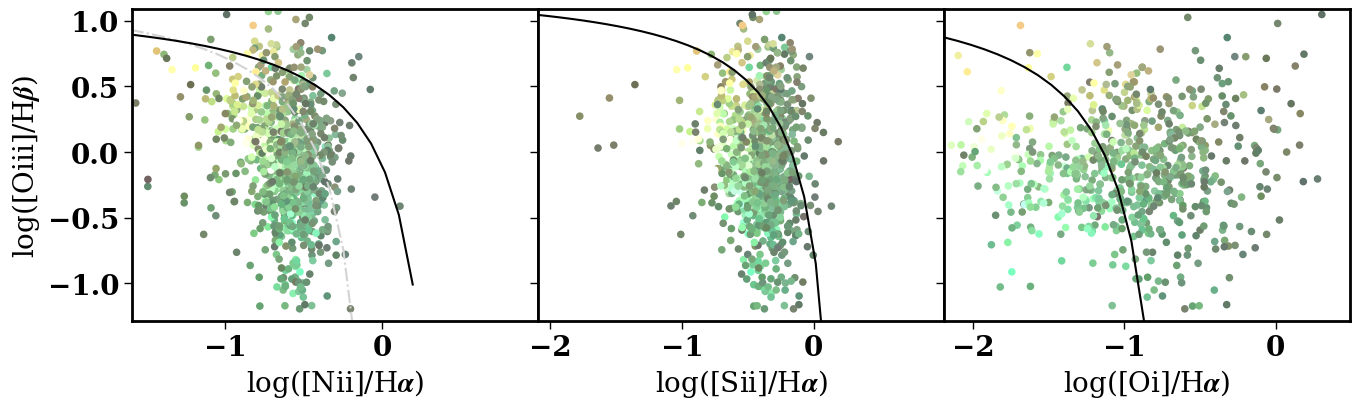

In [13]:
rc.update({'font.size': 20,\
           'font.weight': 900,\
           # 'text.usetex': True,\
           'path.simplify'           :   True,\
           'xtick.labelsize' : 20,\
           'ytick.labelsize' : 20,\
#           'xtick.major.size' : 3.5,\
#           'ytick.major.size' : 3.5,\
           'axes.linewidth'  : 2.0,\
               # Increase the tick-mark lengths (defaults are 4 and 2)
           'xtick.major.size'        :   6,\
           'ytick.major.size'        :   6,\
           'xtick.minor.size'        :   3,\
           'ytick.minor.size'        :   3,\
           'xtick.major.width'       :   1,\
           'ytick.major.width'       :   1,\
           'lines.markeredgewidth'   :   1,\
           'legend.numpoints'        :   1,\
           'xtick.minor.width'       :   1,\
           'ytick.minor.width'       :   1,\
           'legend.frameon'          :   False,\
           'legend.handletextpad'    :   0.3,\
           'font.family'    :   'serif',\
           'mathtext.fontset'        :   'stix',\
           'axes.facecolor' : "w",\
           
          })


#ask_Ha = (tab_DAP['flux_Halpha_6562.85']>100) & (tab_DAP['flux_Halpha_6562.85']>50.0*tab_DAP['e_flux_Halpha_6562.85'])



Ha=tab_DAP['flux_Halpha_6562.85']
Hb=tab_DAP['flux_Hbeta_4861.36']
OIII=tab_DAP['flux_[OIII]_5006.84']
NII=tab_DAP['flux_[NII]_6583.45']
SII=tab_DAP['flux_[SII]_6716.44']+tab_DAP['flux_[SII]_6730.82']
OI=tab_DAP['flux_[OI]_6300.3']
#tab_DAP['flux_pe_3726.03']+tab_DAP['flux_pe_3728.82']

map_dist=np.arange(len(Ha))

eHa=tab_DAP['e_flux_Halpha_6562.85']
eHb=tab_DAP['e_flux_Hbeta_4861.36']
eOIII=tab_DAP['e_flux_[OIII]_5006.84']
eNII=tab_DAP['e_flux_[NII]_6583.45']
eSII=np.sqrt(tab_DAP['e_flux_[SII]_6716.44']**2+tab_DAP['e_flux_[SII]_6730.82']**2)
eOI=tab_DAP['flux_[OI]_6300.3']
#tab_DAP['e_flux_pe_3726.03']+tab_DAP['e_flux_pe_3728.82']

#tab_DAP['e_flux_pe_9531.1']

O3=np.log10(OIII)-np.log10(Hb)
N2=np.log10(NII)-np.log10(Ha)
S2=np.log10(SII/Ha)
O1=np.log10(OI/Ha)
lEW_Ha = np.log10(np.abs(tab_DAP['EW_Halpha_6562.85']))
e_lEW_Ha = 0.4*np.abs(tab_DAP['e_EW_Halpha_6562.85']/tab_DAP['EW_Halpha_6562.85'])
nx = 2.5 #np.max(tab_DAP[mask_Ha]['R_Re'])
#
#
#
fig, axes = plt.subplots(1,3,figsize=(14,4.5), sharey=True, squeeze=False)
x_min1=-1.39
x_max1=0.89
y_min1=-1.29
y_max1=0.99

x=np.linspace(5*x_min1,2*x_max1,100)
cut_y=-0.7+0.2-3.67*x
cut_y2=-1.7+0.5-3.67*x
cut_y3=0.61/(x-0.05)+1.3
cut_y4=0.61/(x-0.47)+1.19
cut_y_SII=0.61/(x-0.3)+1.3;
cut_y_SII=0.61/(x-0.3)+1.3;
cut_y_SII_AGNs=1.89*(x)+0.76;
cut_y_OI=0.73/((x+0.59))+1.33;#+1.10;
cut_y_OI_AGNs=1.18*(x)+1.30;
cut_y_OIII_AGNs=1.14*(x)+0.36;
cm = plt.cm.get_cmap('viridis')
cax1=axes[0,0].scatter(N2[mask_Ha],O3[mask_Ha],color=colors[mask_Ha],edgecolor='None',s=30)
#                       c=map_dist[mask_Ha], marker='o', s=30, alpha=0.35, cmap=cm, vmin=0, vmax=nx)
cax2=axes[0,1].scatter(S2[mask_Ha],O3[mask_Ha],color=colors[mask_Ha],edgecolor='None',s=30)
cax3=axes[0,2].scatter(O1[mask_Ha],O3[mask_Ha],color=colors[mask_Ha],edgecolor='None',s=30)

#axes[0,0].scatter(N2,O3,alpha=0.75, marker='*', s=100,c='green')
#axes[0,1].scatter(S2,O3,alpha=0.75, marker='*', s=100,c='green')
#axes[0,2].scatter(O1,O3,alpha=0.75, marker='*', s=100,c='green')

axes[0,0].plot(x[x<-0.1],cut_y3[x<-0.1],'-.',color='lightgrey')
axes[0,0].plot(x[x<0.2],cut_y4[x<0.2],'-',color='black')
axes[0,1].plot(x[x<0.2],cut_y_SII[x<0.2],'-',color='black')
axes[0,2].plot(x[x<-0.6],cut_y_OI[x<-0.6],'-',color='black')


#plt.rcParams.update({'font.size': 16})
axes[0,0].set_ylabel(r'log([Oiii]/H$\beta$)')
axes[0,0].set_xlabel(r'log([Nii]/H$\alpha$)')
axes[0,1].set_xlabel(r'log([Sii]/H$\alpha$)')
axes[0,2].set_xlabel(r'log([Oi]/H$\alpha$)')
axes[0,0].set_xlim(x_min1-0.2,x_max1+0.1)
axes[0,1].set_xlim(x_min1-0.7,x_max1+0.1)
axes[0,2].set_xlim(x_min1-0.8,x_max1-0.4)
axes[0,0].set_ylim(y_min1,y_max1+0.1)
axes[0,1].set_ylim(y_min1,y_max1+0.1)
axes[0,2].set_ylim(y_min1,y_max1+0.1)






plt.tight_layout()
plt.subplots_adjust(wspace=0)

fig.savefig(f'figs/BPT_HELIX_OI.png', facecolor='white')
plt.show()

#cax1=axes[0,2].scatter(N2[mask_Ha],O3[mask_Ha],c=log_EW_Ha[mask_Ha], marker='o', s=30, alpha=0.35, cmap=cm, vmin=-3, vmax=2.5)
#axes[0,2].plot(x[x<0],cut_y3[x<0],'r-.')
#axes[0,2].plot(x,cut_y4,'b-')
#cb1=add_colorbar(cax1)
#cb1.set_label(r'$log|EW(H\alpha)|$')

## C. Generic map helpers for individual DAP quantities

## 6. Define a generic helper to plot a single DAP quantity on the sky

This function builds a scatter map of one selected DAP column using the fiber sky coordinates.  
It is the basic tool used later for line-flux maps, stellar-parameter maps, velocity maps, and similar products.

Because LVM DAP products are fiber-based rather than image-based, most spatial visualization begins with this sort of function.

In [14]:
def map_plot_DAP(tab_DAP,line='flux_Halpha_6562.85', \
                 vmin=0, vmax=0, title=None, filename='junk',\
                 cmap='Spectral', fsize=5, figs_dir='.',fig_type='png',\
                 gamma=1.0, sf=1.0, tab_pt=None):

    rc.update({'font.size': 19,\
               'font.weight': 900,\
               'text.usetex': True,\
               'path.simplify'           :   True,\
               'xtick.labelsize' : 19,\
               'ytick.labelsize' : 19,\
               'axes.linewidth'  : 2.0,\
               'xtick.major.size'        :   6,\
               'ytick.major.size'        :   6,\
               'xtick.minor.size'        :   3,\
               'ytick.minor.size'        :   3,\
               'xtick.major.width'       :   1,\
               'ytick.major.width'       :   1,\
               'lines.markeredgewidth'   :   1,\
               'legend.numpoints'        :   1,\
               'xtick.minor.width'       :   1,\
               'ytick.minor.width'       :   1,\
               'legend.frameon'          :   False,\
               'legend.handletextpad'    :   0.3,\
               'font.family'    :   'serif',\
               'mathtext.fontset'        :   'stix',\
               'axes.facecolor' : "w",\
               })
    
    X=tab_DAP['ra']
    Y=tab_DAP['dec']
    C=tab_DAP[line]    
    if (title== None):
        title=line.replace("_"," ")
        title=line.replace("_"," ")
    if (vmin==vmax):
        vmin=0.00001*np.nanmax(C)
        vmax=np.nanmax(C)
    print(line,vmin,vmax)
    fig,ax = plt.subplots(1,1,figsize=(fsize,fsize/1.3))
    norm=mpl_colors.PowerNorm(vmin=vmin,vmax=vmax,gamma=gamma)
    scat=scatter(X, Y, ax, size=sf*35.6/3600, c=C, cmap=cmap, norm=norm)

    ax.set_xlabel('Ra [deg]')
    ax.set_ylabel('Dec [deg]')
    xx = ax.get_xlim()
    yy = ax.get_ylim()
    ax.set_xlim(xx[1],xx[0])
    props = dict(boxstyle='square', facecolor='white', alpha=0.5)
    ax.text(xx[1]-0.03*(xx[1]-xx[0]),yy[1]-0.08*(yy[1]-yy[0]),title,color='black',\
            bbox=props)
    ax.text(xx[1]-0.52*(xx[1]-xx[0]),yy[0]+0.06*(yy[1]-yy[0]),r'10$^{-16}$ erg/s/cm$^2$',color='black',\
            bbox=props)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(scat.sc, cax=cax, format='%.0e')
    if (tab_pt != None):
        for tap_pt_now in tab_pt:
            ax.text(tab_pt['ra'],tab_pt['dec'],tab_pt['id'])

    try:
        plt.show()
    except:
        plt_show=False
    fig.tight_layout()
    fig.savefig(f'{figs_dir}/{filename}.{fig_type}')
    plt.close()


This is a slightly more flexible version of the previous helper that plots into a user-provided axis.  
It is ideal for multi-panel figures and for publication layouts.

Most of the science figures in the rest of the notebook are built with this function.

In [15]:
def map_plot_DAP_ax(tab_DAP,ax=None,fig=None,line='flux_Halpha_6562.85', \
                 vmin=0, vmax=0, title=None, filename='junk',\
                 cmap='Spectral', fsize=5, figs_dir='.',fig_type='png',\
                 gamma=1.0, sf=1.0, tab_pt=None,xlab=True,ylab=True, fs=1.0,f_scale=1e7):

    rc.update({'font.size': 19*fs,\
               'font.weight': 900,\
               # 'text.usetex': True,\
               'path.simplify'           :   True,\
               'xtick.labelsize' : 19*fs,\
               'ytick.labelsize' : 19*fs,\
               'axes.linewidth'  : 2.0,\
               'xtick.major.size'        :   6*fs,\
               'ytick.major.size'        :   6*fs,\
               'xtick.minor.size'        :   3*fs,\
               'ytick.minor.size'        :   3*fs,\
               'xtick.major.width'       :   1,\
               'ytick.major.width'       :   1,\
               'lines.markeredgewidth'   :   1,\
               'legend.numpoints'        :   1,\
               'xtick.minor.width'       :   1,\
               'ytick.minor.width'       :   1,\
               'legend.frameon'          :   False,\
               'legend.handletextpad'    :   0.3,\
               'font.family'    :   'serif',\
               'mathtext.fontset'        :   'stix',\
               'axes.facecolor' : "w",\
               })
    
    X=tab_DAP['ra']
    Y=tab_DAP['dec']
    C=tab_DAP[line]/f_scale    
    if (title== None):
        title=line.replace("_"," ")
        title=line.replace("_"," ")
    if (vmin==vmax):
        vmin=0.00001*np.nanmax(C)
        vmax=np.nanmax(C)

    if (gamma>0):
        norm=mpl_colors.PowerNorm(vmin=vmin,vmax=vmax,gamma=gamma)
        size_sc = sf*35.6/3600
        scat=ax.scatter(X, Y, s=10*sf, c=C, cmap=cmap, norm=norm, rasterized=True)
    else:

        scat=ax.scatter(X, Y, s=10*sf, c=C, cmap=cmap, vmin=vmin, vmax=vmax, rasterized=True)

    if (xlab == True):
        ax.set_xlabel('Ra [deg]',fontsize=19*fs)
    if (ylab == True):
        ax.set_ylabel('Dec [deg]',fontsize=19*fs)
    xx = ax.get_xlim()
    yy = ax.get_ylim()
    ax.set_xlim(xx[1],xx[0])
    props = dict(boxstyle='square', facecolor='white', alpha=0.5)
    ax.text(xx[1]-0.03*(xx[1]-xx[0]),yy[1]-0.08*fs*(yy[1]-yy[0]),rf'{title}',color='black',\
            bbox=props)

    return scat



## Comparison of Hα flux products

The left panel shows the spatial distribution of the Hα flux derived from the **non-parametric** DAP analysis, which is the most convenient product for mapping the nebular emission over the full field. The right panel compares the Hα flux measured with the non-parametric method against the value derived from the **second parametric fit** (`PEK`), which is optimized for strong lines after refinement of the stellar-continuum subtraction. Agreement between both measurements indicates that the line is robustly recovered, while deviations usually become more important in low-signal fibers or in regions affected by background residuals.

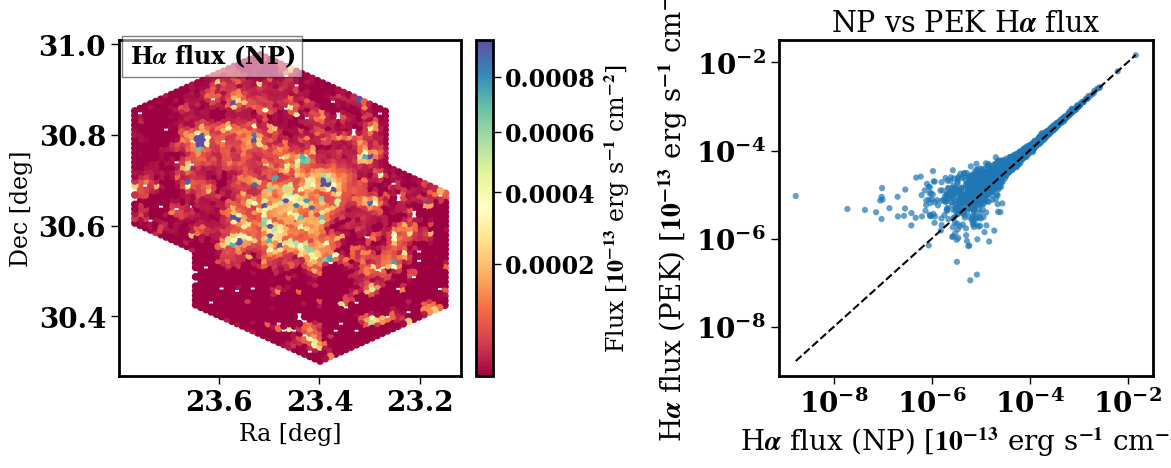

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --------------------------------------------------
# Left panel: Halpha flux map (NP measurement)
# --------------------------------------------------
line_np = 'flux_Halpha_6562.85'

C_np = tab_DAP[line_np] / 1e7
good_map = np.isfinite(C_np) & (C_np > 0)

if np.any(good_map):
    vmin_map = np.nanpercentile(C_np[good_map], 5)
    vmax_map = np.nanpercentile(C_np[good_map], 99)
else:
    vmin_map, vmax_map = 0, 1

scat = map_plot_DAP_ax(
    tab_DAP,
    ax=axes[0],
    line=line_np,
    vmin=vmin_map,
    vmax=vmax_map,
    title=r'H$\alpha$ flux (NP)',
    cmap='Spectral',
    gamma=0.7,
    sf=2,
    xlab=True,
    ylab=True,
    fs=0.9,
    f_scale=1e7
)

cb = fig.colorbar(scat, ax=axes[0], fraction=0.046, pad=0.04)
cb.set_label(r'Flux [$10^{-13}$ erg s$^{-1}$ cm$^{-2}$]')

# --------------------------------------------------
# Right panel: NP vs PEK comparison
# --------------------------------------------------
line_pek = 'flux_pek_6562.85'

Ha_np = tab_DAP[line_np]
Ha_pek = tab_DAP[line_pek]

mask = (
    np.isfinite(Ha_np) & np.isfinite(Ha_pek) &
    (Ha_np > 0) & (Ha_pek > 0)
)

axes[1].scatter(
    Ha_np[mask] / 1e7,
    Ha_pek[mask] / 1e7,
    s=20,
    alpha=0.7,
    edgecolor='none'
)

if np.any(mask):
    lo = min(np.nanmin(Ha_np[mask]), np.nanmin(Ha_pek[mask])) / 1e7
    hi = max(np.nanmax(Ha_np[mask]), np.nanmax(Ha_pek[mask])) / 1e7
    axes[1].plot([lo, hi], [lo, hi], '--', color='black', lw=1.5)

axes[1].set_xlabel(r'H$\alpha$ flux (NP) [$10^{-13}$ erg s$^{-1}$ cm$^{-2}$]')
axes[1].set_ylabel(r'H$\alpha$ flux (PEK) [$10^{-13}$ erg s$^{-1}$ cm$^{-2}$]')
axes[1].set_title(r'NP vs PEK H$\alpha$ flux')
axes[1].set_xscale('log')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

## D. Kinematics and line-by-line spatial structure

## 7. Hα kinematics: velocity and velocity dispersion

This figure reproduces one of the core physical results of the Helix analysis:
- the Hα velocity field,
- and the Hα velocity-dispersion field.

In the Helix paper, the velocity map shows a large-scale redshifted/blueshifted symmetry consistent with a slowly expanding, moderately inclined shell.  
The velocity-dispersion map is generally narrow, with somewhat broader profiles in the inner cavity and the brightest ring, consistent with thermal broadening plus modest unresolved turbulent motions.

Mean velocity in central region: -182.75 km/s


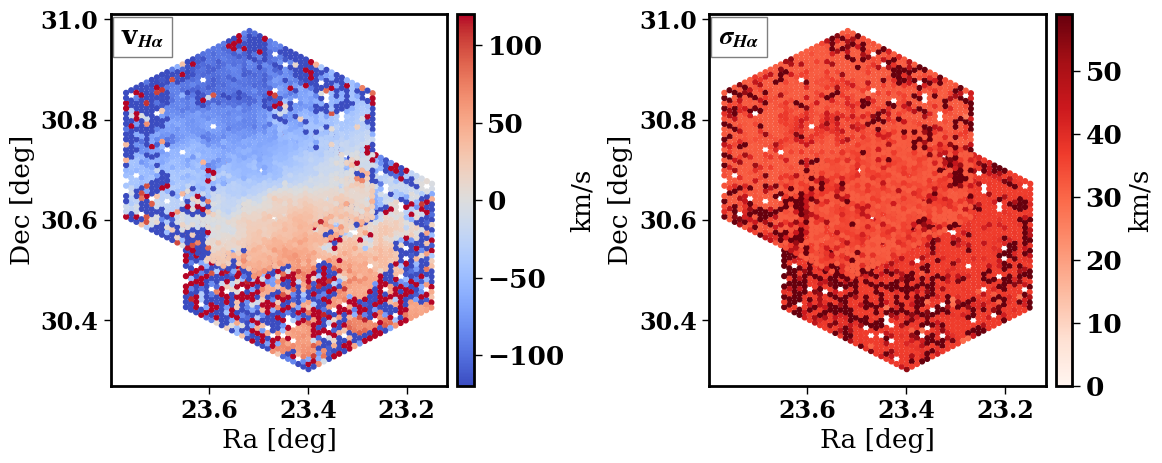

In [17]:
fig, axes = plt.subplots(1,2,figsize=(12,5))
#cmap_now = 'Spectral_r'
#cmap_now = 'turbo'
cmap_now = 'coolwarm'
#np.zeros(len(tab_DAP),dtype=int)
filename=f'M33_{DRVER}_kin'
xlab = True
ylab = True
ax = axes[0]
dec_c = 30.65
ra_c = 23.45
mask_cen = ((tab_DAP['dec']>(30.65-0.025)) & (tab_DAP['dec']<(30.65+0.025))) & ((tab_DAP['ra']>(23.45-0.05)) & (tab_DAP['ra']<(23.45+0.05)))        
mean_vel = np.nanmedian(tab_DAP['vel_pek_6562.85'][mask_cen])
print(f'Mean velocity in central region: {mean_vel:.2f} km/s')
tab_DAP['vel_off'] = tab_DAP['vel_pek_6562.85'] - mean_vel
scat=map_plot_DAP_ax(tab_DAP,ax=ax,fig=fig,line='vel_off', \
                 vmin=-120, vmax=120, title=r'v$_{H\alpha}$', filename=filename,\
             cmap=cmap_now, fsize=6.5, figs_dir='figs',gamma=0,fig_type='pdf',\
                         xlab=xlab,ylab=ylab,sf=1.2,fs=1.0,\
                        f_scale=1.0)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
fig.colorbar(scat, cax=cax, label='km/s')#,label=fr'{title}')#,fontsize=21)

ax = axes[1]
scat=map_plot_DAP_ax(tab_DAP,ax=ax,fig=fig,line='sigma_kms_pek_6562.85', \
                 vmin=0, vmax=59, title=r'$\sigma_{H\alpha}$', filename=filename,\
             cmap='Reds', fsize=6.5, figs_dir='figs',gamma=0,fig_type='pdf',\
                         xlab=xlab,ylab=ylab,sf=1.2,fs=1.0,\
                        f_scale=1.0)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
fig.colorbar(scat, cax=cax, label='km/s')#,label=fr'{title}')#,fontsize=21)

#ax.set_ylabel('')


plt.tight_layout(w_pad=0.5)


fig.savefig(f'{DIR_FIG}/kin.pdf', facecolor='white')


Mean velocity in central region: -322.89 km/s


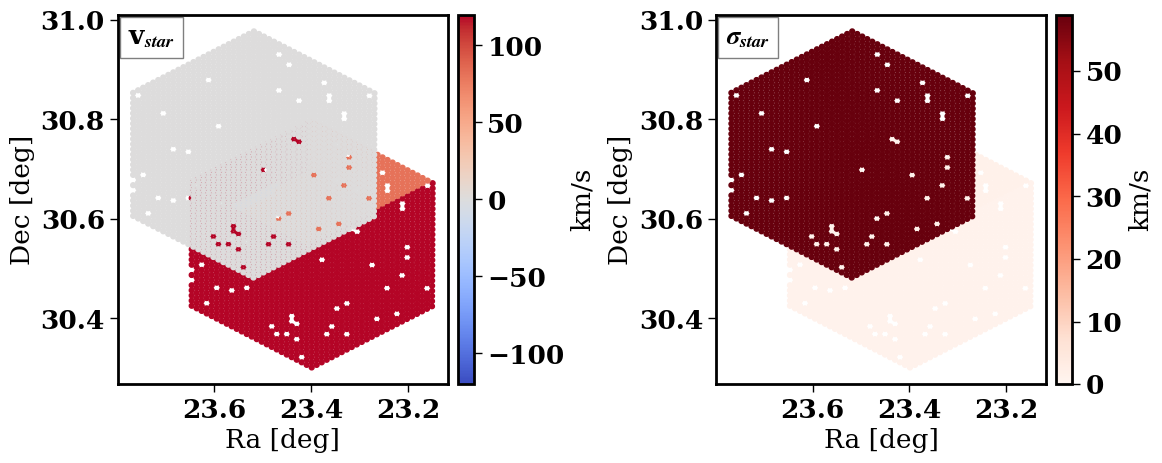

In [18]:
fig, axes = plt.subplots(1,2,figsize=(12,5))
#cmap_now = 'Spectral_r'
#cmap_now = 'turbo'
cmap_now = 'coolwarm'
#np.zeros(len(tab_DAP),dtype=int)
filename=f'M33_{DRVER}_kin'
xlab = True
ylab = True
ax = axes[0]
dec_c = 30.65
ra_c = 23.45
mask_cen = ((tab_DAP['dec']>(30.65-0.025)) & (tab_DAP['dec']<(30.65+0.025))) & ((tab_DAP['ra']>(23.45-0.05)) & (tab_DAP['ra']<(23.45+0.05)))        
mean_vel = np.nanmedian(tab_DAP['vel_st'][mask_cen])
print(f'Mean velocity in central region: {mean_vel:.2f} km/s')
tab_DAP['vel_off_st'] = tab_DAP['vel_st'] - mean_vel
scat=map_plot_DAP_ax(tab_DAP,ax=ax,fig=fig,line='vel_off_st', \
                 vmin=-120, vmax=120, title=r'v$_{star}$', filename=filename,\
             cmap=cmap_now, fsize=6.5, figs_dir='figs',gamma=0,fig_type='pdf',\
                         xlab=xlab,ylab=ylab,sf=1.2,fs=1.0,\
                        f_scale=1.0)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
fig.colorbar(scat, cax=cax, label='km/s')#,label=fr'{title}')#,fontsize=21)

ax = axes[1]
scat=map_plot_DAP_ax(tab_DAP,ax=ax,fig=fig,line='disp_st', \
                 vmin=0, vmax=59, title=r'$\sigma_{star}$', filename=filename,\
             cmap='Reds', fsize=6.5, figs_dir='figs',gamma=0,fig_type='pdf',\
                         xlab=xlab,ylab=ylab,sf=1.2,fs=1.0,\
                        f_scale=1.0)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
fig.colorbar(scat, cax=cax, label='km/s')#,label=fr'{title}')#,fontsize=21)

#ax.set_ylabel('')


plt.tight_layout(w_pad=0.5)


fig.savefig(f'{DIR_FIG}/kin.pdf', facecolor='white')


## G. Explore the stellar-continuum side of the DAP products

## 8. Select fibers with measurable stellar continuum

This section turns from gas to the stellar side of the DAP.  
The Helix is not an ideal field for stellar-population work because the nebula dominates and only a few fibers contain stars with moderate signal-to-noise.

The selection `SN_st > 5` is therefore a practical exploratory cut rather than a physically complete sample.

In [19]:
#
# Stars with SN>3
#
SN_st = tab_DAP['med_flux_st']/tab_DAP['e_med_flux_st']
mask_SN = SN_st > 10
tab_DAP['SN_st'] = SN_st
tab_DAP_st = tab_DAP[mask_SN]

This cell resets the plotting style for the stellar-parameter section.

In [20]:
rc.update({'font.size': 20,\
           'font.weight': 900,\
           # 'text.usetex': True,\
           'path.simplify'           :   True,\
           'xtick.labelsize' : 20,\
           'ytick.labelsize' : 20,\
           'axes.linewidth'  : 2.0,\
               # Increase the tick-mark lengths (defaults are 4 and 2)
           'xtick.major.size'        :   6,\
           'ytick.major.size'        :   6,\
           'xtick.minor.size'        :   3,\
           'ytick.minor.size'        :   3,\
           'xtick.major.width'       :   1,\
           'ytick.major.width'       :   1,\
           'lines.markeredgewidth'   :   1,\
           'legend.numpoints'        :   1,\
           'xtick.minor.width'       :   1,\
           'ytick.minor.width'       :   1,\
           'legend.frameon'          :   False,\
           'legend.handletextpad'    :   0.3,\
           'font.family'    :   'serif',\
           'mathtext.fontset'        :   'stix',\
           'axes.facecolor' : "w",\
           
          })


This scatter plot shows the distribution of the DAP-derived stellar metallicity proxy `[Fe/H]` and alpha-enhancement `[α/Fe]` for the selected stellar fibers. Keep in min that those are "average" properties from a combination of stars analyzed using the RSP methodology. For a proper PDF we provide with a methodology included below.

For the Helix field, these points should be treated as field-star measurements.  
The Helix paper explicitly warns that the stellar results are not robust enough here to support physical conclusions about the nebula itself.

Text(0, 0.5, '[$\\alpha$/Fe]')

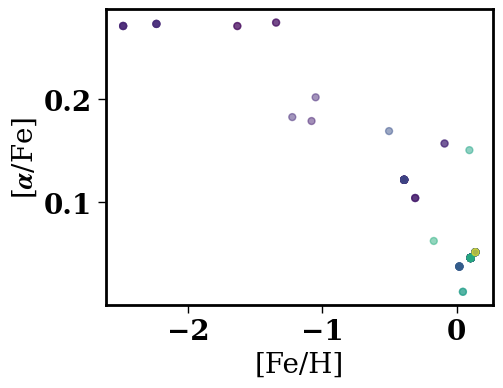

In [21]:
dist_c = np.sqrt((tab_DAP_st['ra']-ra_c)**2+(tab_DAP_st['dec']-dec_c)**2)
dist_c_st = np.sqrt((tab_DAP_st['ra']-ra_c)**2+(tab_DAP_st['dec']-dec_c)**2)
fig, ax = plt.subplots(1,1,figsize=(5,5/1.3))
ax.scatter(tab_DAP_st['Fe'],tab_DAP_st['alpha'],s=25,c=dist_c_st,alpha=0.5)
ax.set_xlabel('[Fe/H]')
ax.set_ylabel(r'[$\alpha$/Fe]')

This scatter plot shows the distribution in `Teff` versus `log g` for the selected stellar fibers.  
Again, the point is mainly diagnostic: it reveals what part of parameter space is sampled by the stars bright enough to be detected in the field.

Text(0, 0.5, 'log(g)')

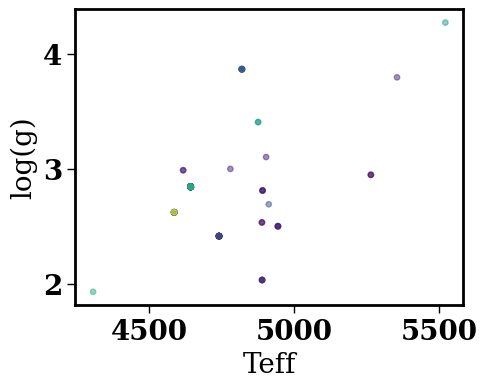

In [22]:
fig, ax = plt.subplots(1,1,figsize=(5,5/1.3))
ax.scatter(tab_DAP_st['Teff'],tab_DAP_st['Log_g'],s=15,c=dist_c_st,alpha=0.5)
ax.set_xlabel('Teff')
ax.set_ylabel(r'log(g)')

### About this notebook

This notebook demonstrated how to create Mosaics using the the DAP-files (https://github.com/sdss/lvmdap).

**Authors**: Sebastian F. Sanchez and the LVM team

**Last Update**: 2026 April 21

If you use `astropy`  for published research, please cite the
authors. Follow this link for more information about citing `astropy`:

* [Citing `astropy`](https://www.astropy.org/acknowledging.html)

And of course please [cite](https://sdss.org/collaboration/citing-sdss/) SDSS when you use our data.